In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

hemantthegood_flowers_data_path = kagglehub.dataset_download('hemantthegood/flowers-data')
hemantthegood_flower_test_data_path = kagglehub.dataset_download('hemantthegood/flower-test-data')

print('Data source import complete.')


100%|██████████| 340M/340M [00:05<00:00, 65.2MB/s]

Extracting files...


100%|██████████| 67.6k/67.6k [00:00<00:00, 40.1MB/s]

Extracting files...
Data source import complete.


**In this notebook we will train model to classify flower in 14 categories and export it to onxx, to deploy.**

In [3]:
import os
import numpy as np # linear algebra
from fastcore.all import *
from fastai.vision.all import *
import time, json
from pathlib import Path

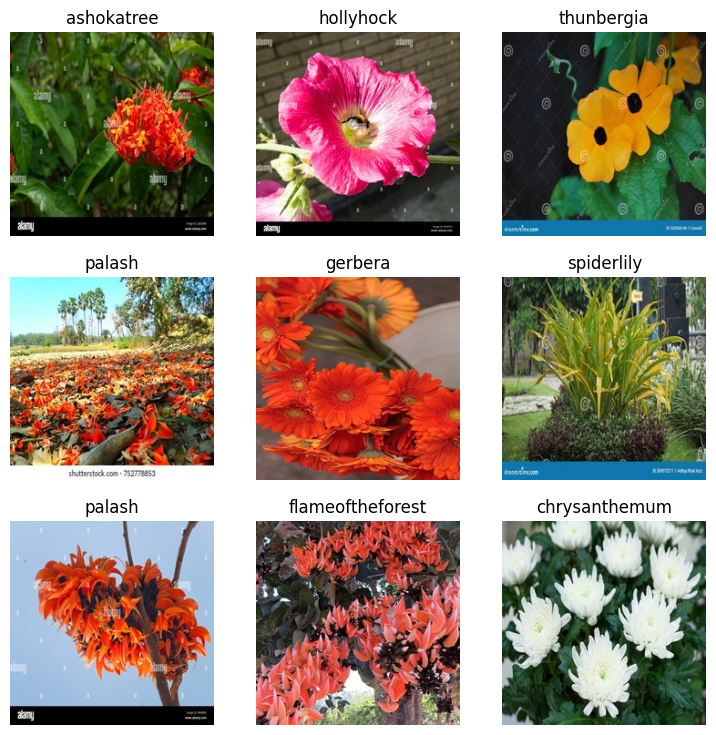

In [4]:
# Create Dataloader
path = hemantthegood_flowers_data_path
dls = ImageDataLoaders.from_folder(
    path,
    item_tfms=Resize(224),  # Resize images to 224x224
    valid_pct=0.2,
)
dls.show_batch()

**Train**

In [5]:
learn = vision_learner(dls, convnext_tiny, metrics=error_rate)
learn.fine_tune(3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 182MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.409050,1.233604,0.336536,02:07


epoch,train_loss,valid_loss,error_rate,time
0,1.257641,0.859740,0.237555,04:00
1,0.854744,0.656848,0.187773,04:00
2,0.633472,0.620898,0.176710,04:02


In [5]:
from huggingface_hub import hf_hub_download
# Download your model from Hugging Face Hub
model_id = "hemu312/flower-classification_convnext"
model_path = hf_hub_download(repo_id=model_id, filename="flower-classification_convnext.pt")
learn1 = vision_learner(dls, convnext_tiny, metrics=error_rate)
learn1.model = torch.jit.load(model_path)
learn1.fine_tune(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flower-classification_convnext.pt:   0%|          | 0.00/115M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 184MB/s] 


epoch,train_loss,valid_loss,error_rate,time


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
learn=load_learner("/content/flower-classification_convnext.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [8]:
class_names = learn.dls.vocab
print(class_names)
import json
with open('class_names.json', 'w') as f:
    json.dump(list(class_names), f)

['agapanthus', 'alyssum', 'amaltas', 'anthurium', 'antirrhinum', 'ashokatree', 'balsam', 'birdofparadise', 'bottlebrushtree', 'bougainvillea', 'butterflypea', 'callalily', 'candytuft', 'carnation', 'champak', 'chrysanthemum', 'cockscomb', 'cosmos', 'crossandra', 'dahlia', 'flameoftheforest', 'fouroclockflower', 'gaillardia', 'gerbera', 'gladiolus', 'goldenshowertree', 'gulmohar', 'heliconia', 'hibiscus', 'hollyhock', 'impatiens', 'indiancoraltree', 'indianlaburnumcopperpod', 'ixora', 'jacaranda', 'jasmine', 'kachnar', 'lantana', 'larkspur', 'lotus', 'marigold', 'mexicanpetunia', 'millingtonia', 'nightqueen', 'oleander', 'palash', 'peacockflower', 'pentas', 'periwinkle', 'petunia', 'phlox', 'pinktrumpettree', 'plumeria', 'portulaca', 'prideofindia', 'rainlily', 'rangooncreeper', 'rose', 'salvia', 'silkcottontree', 'spiderlily', 'stockflower', 'sunflower', 'thunbergia', 'torchginger', 'torchlily', 'torenia', 'trumpettree', 'tuberose', 'verbena', 'vinca', 'zinnia']


**Test**

In [9]:
result,_,probs = learn.predict(PILImage.create(hemantthegood_flower_test_data_path+"/testImg.jpg"))
print(f"Flower is {result} with probability {probs.max()}")

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [10]:
import torch
scripted_model = torch.jit.script(learn.model)
scripted_model.save("/content/flower-classification_convnext.pt")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(5, nrows=2)

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
img = PILImage.create(hemantthegood_flower_test_data_path)

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 13.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.4 MB/s eta 0:00:00


In [ ]:
print(learn.dls.train.one_batch()[0].shape)

torch.Size([64, 3, 224, 224])


In [ ]:
?learn.fine_tune

Signature:
learn.fine_tune(
    epochs,
    base_lr=0.002,
    freeze_epochs=1,
    lr_mult=100,
    pct_start=0.3,
    div=5.0,
    *,
    lr_max=None,
    div_final=100000.0,
    wd=None,
    moms=None,
    cbs=None,
    reset_opt=False,
    start_epoch=0,
)
Docstring: Fine tune with `Learner.freeze` for `freeze_epochs`, then with `Learner.unfreeze` for `epochs`, using discriminative LR.
File:      /usr/local/lib/python3.12/dist-packages/fastai/callback/schedule.py
Type:      method
